# Melbourne Bike Share Station Readings 2011–2017
## Exploratory Data Analysis & Demand Pattern Analysis

**Project 8: Urban Bike Sharing Demand Prediction with Graphical Learning**  
**Chameleon – MOP DS, AI & IoT | Deakin University T1 2026**  
**Author: Viswa Sai Mandava**

---

This notebook covers the initial exploration of the Melbourne Bike Share dataset.
The analysis is structured around three use cases:
1. Identifying peak demand periods and high-pressure stations
2. Predicting short-term bike availability
3. Predicting empty dock availability for returns

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load the Dataset

In [4]:
df = pd.read_csv('74id-aqj9.csv', low_memory=False)

print(f'Dataset shape: {df.shape}')
print(f'Number of rows: {df.shape[0]:,}')
print(f'Number of columns: {df.shape[1]}')
df.head(10)

Dataset shape: (5644554, 16)
Number of rows: 5,644,554
Number of columns: 16


,ID,NAME,TERMINALNAME,NBBIKES,NBEMPTYDOCKS,RUNDATE,INSTALLED,TEMPORARY,LOCKED,LASTCOMMWITHSERVER,LATESTUPDATETIME,REMOVALDATE,INSTALLDATE,LAT,LONG,LOCATION
0,2,Harbour Town - Docklands Dve - Docklands,60000,10,11,20170422134506,True,False,False,1492832566010,1.492833e+12,NaN,1.313725e+12,-37.814022,144.939521,"(-37.814022, 144.939521)"
1,4,Federation Square - Flinders St / Swanston St ...,60001,9,18,20170422134506,True,False,False,1492832631727,1.492832e+12,NaN,NaN,-37.817523,144.967814,"(-37.817523, 144.967814)"
2,6,State Library - Swanston St / Little Lonsdale ...,60003,1,10,20170422134506,True,False,False,1492832015231,1.492832e+12,NaN,NaN,-37.810702,144.964417,"(-37.810702, 144.964417)"
3,7,Bourke Street Mall - 205 Bourke St - City,60004,4,7,20170422134506,True,False,False,1492832218661,1.492830e+12,NaN,NaN,-37.813088,144.967437,"(-37.813088, 144.967437)"
4,8,Melbourne Uni - Tin Alley - Carlton,60005,8,11,20170422134506,True,False,False,1492832103674,1.492769e+12,NaN,NaN,-37.796250,144.960858,"(-37.79625, 144.960858)"
5,9,RMIT - Swanston St / Franklin St - City,60006,3,4,20170422134506,True,False,False,1492831955565,1.492831e+12,NaN,1.356556e+12,-37.807699,144.963095,"(-37.807699, 144.963095)"
6,10,St Paul's Cathedral - Swanston St / Flinders S...,60007,7,4,20170422134506,True,False,False,1492832492347,1.492826e+12,NaN,NaN,-37.817189,144.967409,"(-37.817189, 144.967409)"
7,11,MSAC - Aughtie Dve - Albert Park,60008,12,15,20170422134506,True,False,False,1492832082173,1.492832e+12,NaN,NaN,-37.842395,144.961868,"(-37.842395, 144.961868)"
8,12,Fitzroy Town Hall - Moor St - Fitzroy,60009,11,0,20170422134506,True,False,False,1492832193207,1.492826e+12,NaN,NaN,-37.801813,144.979209,"(-37.801813, 144.979209)"
9,14,Plum Garland Reserve - Beaconsfield Pde - Albe...,60010,6,13,20170422134506,True,False,False,1492832270326,1.492832e+12,NaN,1.277175e+12,-37.847795,144.948351,"(-37.847795, 144.948351)"


## 3. Basic Dataset Information

In [6]:
print('Column names and data types:')
print(df.dtypes)
print()
print('Basic info:')
df.info()

Column names and data types:
ID                      int64
NAME                   object
TERMINALNAME            int64
NBBIKES                 int64
NBEMPTYDOCKS            int64
RUNDATE                 int64
INSTALLED                bool
TEMPORARY                bool
LOCKED                   bool
LASTCOMMWITHSERVER      int64
LATESTUPDATETIME      float64
REMOVALDATE           float64
INSTALLDATE           float64
LAT                   float64
LONG                  float64
LOCATION               object
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5644554 entries, 0 to 5644553
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ID                  int64  
 1   NAME                object 
 2   TERMINALNAME        int64  
 3   NBBIKES             int64  
 4   NBEMPTYDOCKS        int64  
 5   RUNDATE             int64  
 6   INSTALLED           bool   
 7   TEMPORARY           bool   
 8   LOCKED          

In [8]:
print('Summary statistics for numeric columns:')
df[['NBBIKES', 'NBEMPTYDOCKS']].describe()

Summary statistics for numeric columns:


,NBBIKES,NBEMPTYDOCKS
count,5.644554e+06,5.644554e+06
mean,9.308237e+00,8.446449e+00
std,6.280732e+00,6.047988e+00
min,0.000000e+00,0.000000e+00
25%,5.000000e+00,4.000000e+00
50%,8.000000e+00,7.000000e+00
75%,1.200000e+01,1.200000e+01
max,3.900000e+01,3.900000e+01


## 4. Missing Value Analysis

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
})

print('Missing value summary:')
print(missing_df[missing_df['Missing Values'] > 0])

Missing value summary:
                  Missing Values  Percentage (%)
LATESTUPDATETIME            1225            0.02
REMOVALDATE              5644554          100.00
INSTALLDATE              1242587           22.01


## 5. Date and Time Parsing

The `RUNDATE` column is in format `YYYYMMDDHHMMSS`. We will parse it into a proper datetime and extract time-based features.

In [13]:
df['RUNDATE'] = df['RUNDATE'].astype(str)
df['datetime'] = pd.to_datetime(df['RUNDATE'], format='%Y%m%d%H%M%S', errors='coerce')

# Extract time features
df['hour']        = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek   # 0=Monday, 6=Sunday
df['day_name']    = df['datetime'].dt.day_name()
df['month']       = df['datetime'].dt.month
df['month_name']  = df['datetime'].dt.month_name()
df['year']        = df['datetime'].dt.year
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

print('Date range in dataset:')
print(f'  From : {df["datetime"].min()}')
print(f'  To   : {df["datetime"].max()}')
print(f'  Total unique stations: {df["NAME"].nunique()}')
print(f'  Total unique run dates: {df["datetime"].nunique():,}')
df[['RUNDATE', 'datetime', 'hour', 'day_name', 'month', 'year', 'is_weekend']].head()

Date range in dataset:
  From : 2015-04-22 12:36:42
  To   : 2018-09-04 10:00:10
  Total unique stations: 119
  Total unique run dates: 221,207


,RUNDATE,datetime,hour,day_name,month,year,is_weekend
0,20170422134506,2017-04-22 13:45:06,13,Saturday,4,2017,1
1,20170422134506,2017-04-22 13:45:06,13,Saturday,4,2017,1
2,20170422134506,2017-04-22 13:45:06,13,Saturday,4,2017,1
3,20170422134506,2017-04-22 13:45:06,13,Saturday,4,2017,1
4,20170422134506,2017-04-22 13:45:06,13,Saturday,4,2017,1


## 6. Station Overview

In [16]:
station_summary = df.groupby('NAME').agg(
    avg_bikes        = ('NBBIKES', 'mean'),
    avg_empty_docks  = ('NBEMPTYDOCKS', 'mean'),
    total_readings   = ('NBBIKES', 'count')
).round(2).sort_values('avg_bikes', ascending=False)

print(f'Total number of stations: {len(station_summary)}')
print()
print('Top 10 stations by average bikes available:')
print(station_summary.head(10))

Total number of stations: 119

Top 10 stations by average bikes available:
                                                    avg_bikes  \
NAME                                                            
Luna Park - Lower Esp - St Kilda                        27.20   
St Kilda - Luna Park                                    25.60   
Waterfront City - New Quay / Harbour Esplanade ...      23.67   
Beach St  Port Melbourne                                21.47   
Southern Cross Station - Spencer St - City              18.77   
Federation Square                                       18.57   
MSAC - Aughtie Dve - Albert Park                        17.76   
St Kilda - Fitzroy Street                               17.76   
Sandridge Bridge  Southbank                             17.72   
Southern Cross Station                                  17.20   

                                                    avg_empty_docks  \
NAME                                                                  
Lu

## 7. Use Case 1: Identifying Peak Demand Periods and High-Pressure Stations

A station is under pressure when it is either close to empty (low bike count) or close to full (low empty docks). We define pressure thresholds as:
- **Nearly empty**: NBBIKES <= 2
- **Nearly full**: NBEMPTYDOCKS <= 2

In [19]:
df['nearly_empty'] = (df['NBBIKES'] <= 2).astype(int)
df['nearly_full']  = (df['NBEMPTYDOCKS'] <= 2).astype(int)
df['under_pressure'] = ((df['nearly_empty'] == 1) | (df['nearly_full'] == 1)).astype(int)

pressure_rate = df['under_pressure'].mean() * 100
empty_rate    = df['nearly_empty'].mean() * 100
full_rate     = df['nearly_full'].mean() * 100

print(f'Overall pressure rate (nearly empty OR nearly full): {pressure_rate:.1f}%')
print(f'Nearly empty rate (NBBIKES <= 2)                   : {empty_rate:.1f}%')
print(f'Nearly full rate  (NBEMPTYDOCKS <= 2)              : {full_rate:.1f}%')

Overall pressure rate (nearly empty OR nearly full): 26.1%
Nearly empty rate (NBBIKES <= 2)                   : 11.2%
Nearly full rate  (NBEMPTYDOCKS <= 2)              : 15.0%


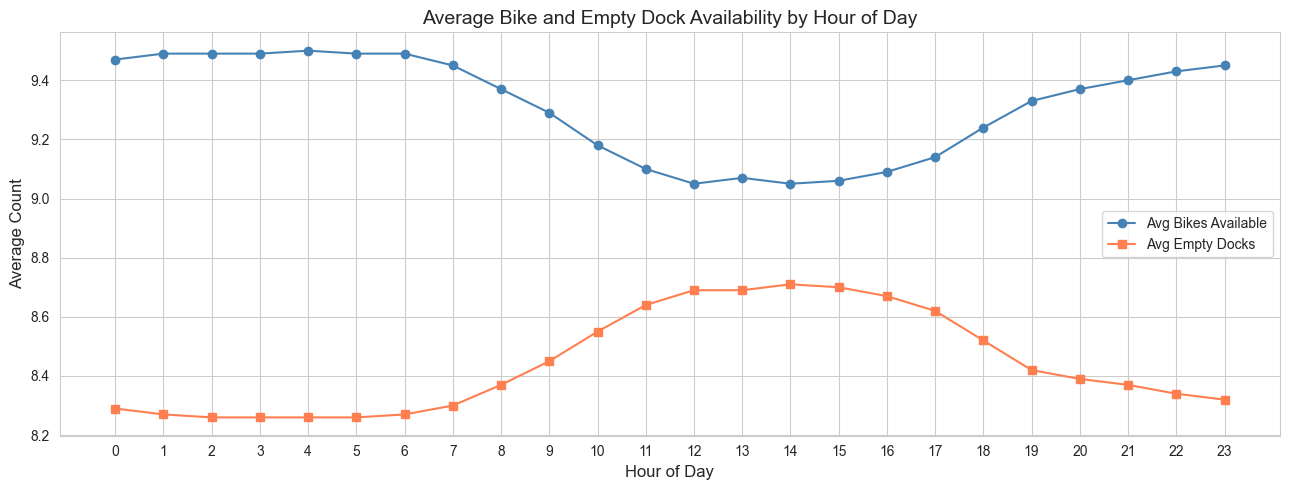

Plot saved.


In [21]:
# Average bikes available by hour of day
hourly = df.groupby('hour')[['NBBIKES', 'NBEMPTYDOCKS']].mean().round(2)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hourly.index, hourly['NBBIKES'], marker='o', color='steelblue', label='Avg Bikes Available')
ax.plot(hourly.index, hourly['NBEMPTYDOCKS'], marker='s', color='coral', label='Avg Empty Docks')
ax.set_title('Average Bike and Empty Dock Availability by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Count')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('hourly_availability.png', dpi=150)
plt.show()
print('Plot saved.')

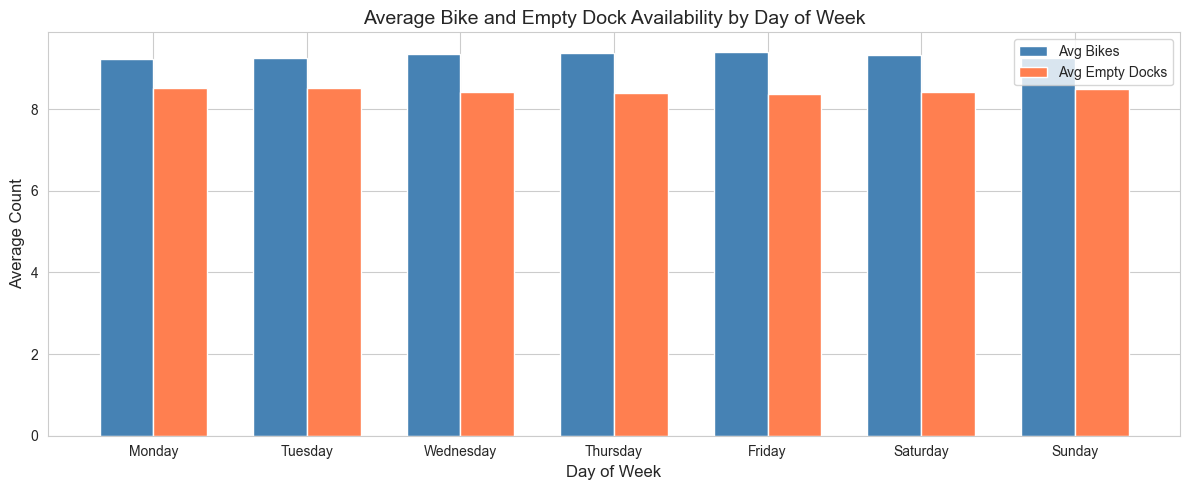

Plot saved.


In [23]:
# Average bikes by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df.groupby('day_name')[['NBBIKES', 'NBEMPTYDOCKS']].mean().reindex(day_order).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(day_order))
width = 0.35
ax.bar([i - width/2 for i in x], daily['NBBIKES'], width, color='steelblue', label='Avg Bikes')
ax.bar([i + width/2 for i in x], daily['NBEMPTYDOCKS'], width, color='coral', label='Avg Empty Docks')
ax.set_title('Average Bike and Empty Dock Availability by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Count')
ax.set_xticks(list(x))
ax.set_xticklabels(day_order)
ax.legend()
plt.tight_layout()
plt.savefig('daily_availability.png', dpi=150)
plt.show()
print('Plot saved.')

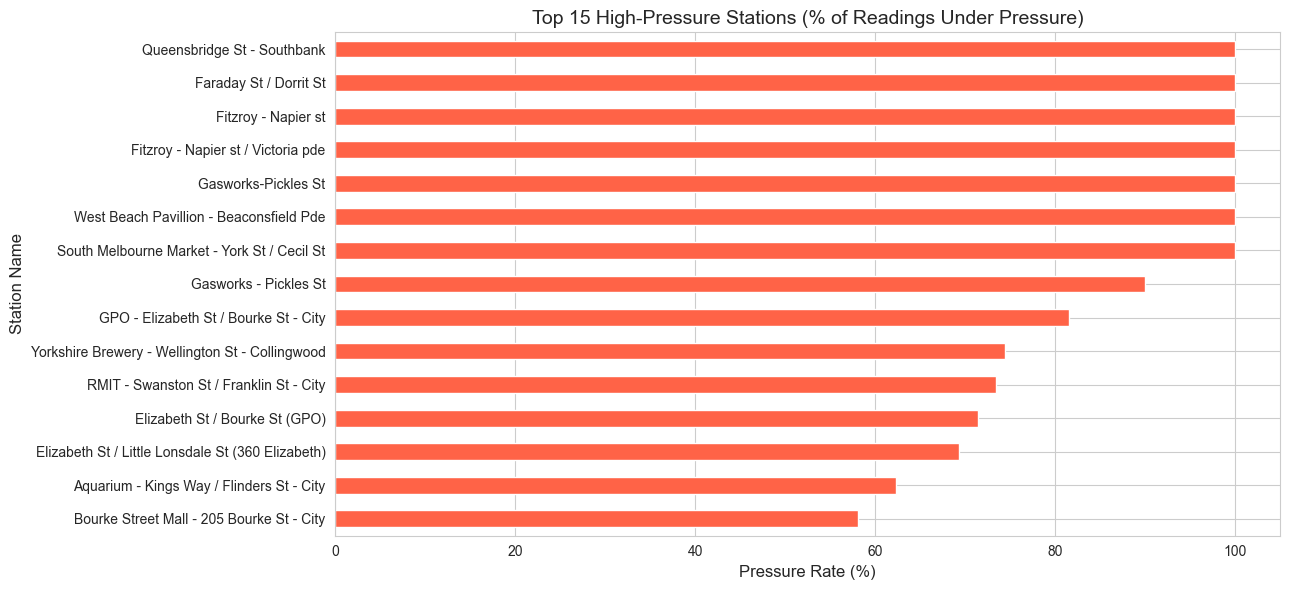

Plot saved.


In [25]:
# Top 15 high-pressure stations (most frequently nearly empty or nearly full)
pressure_by_station = df.groupby('NAME')['under_pressure'].mean().sort_values(ascending=False).head(15) * 100

fig, ax = plt.subplots(figsize=(13, 6))
pressure_by_station.sort_values().plot(kind='barh', color='tomato', ax=ax)
ax.set_title('Top 15 High-Pressure Stations (% of Readings Under Pressure)')
ax.set_xlabel('Pressure Rate (%)')
ax.set_ylabel('Station Name')
plt.tight_layout()
plt.savefig('high_pressure_stations.png', dpi=150)
plt.show()
print('Plot saved.')

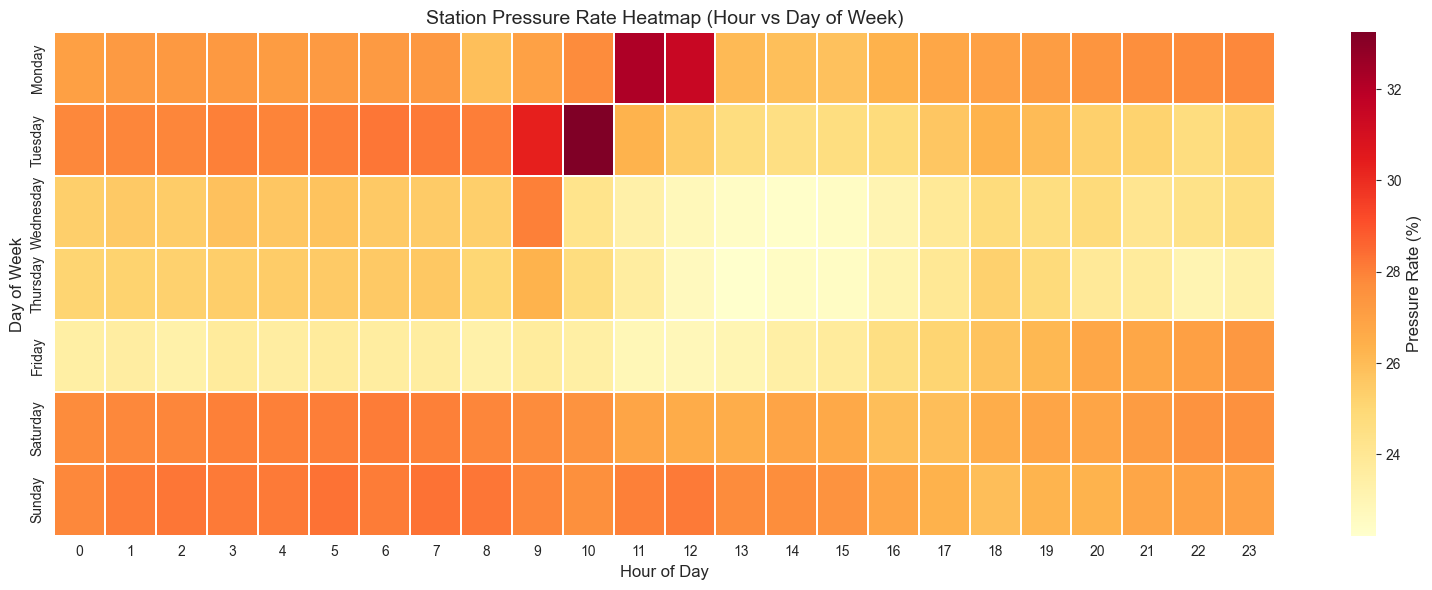

Plot saved.


In [27]:
# Heatmap: pressure rate by hour and day of week
heatmap_data = df.groupby(['day_name', 'hour'])['under_pressure'].mean().unstack() * 100
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Pressure Rate (%)'})
ax.set_title('Station Pressure Rate Heatmap (Hour vs Day of Week)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('pressure_heatmap.png', dpi=150)
plt.show()
print('Plot saved.')

## 8. Use Case 2 & 3: Feature Engineering for Bike and Dock Availability Prediction

To prepare for short-term forecasting, we create lag features and rolling averages that can be used as inputs to a prediction model.

In [30]:
# Sort by station and datetime before creating lag features
df_sorted = df.sort_values(['NAME', 'datetime']).copy()

# Lag features: previous 1, 2, 3 readings per station
for lag in [1, 2, 3]:
    df_sorted[f'bikes_lag_{lag}']  = df_sorted.groupby('NAME')['NBBIKES'].shift(lag)
    df_sorted[f'docks_lag_{lag}']  = df_sorted.groupby('NAME')['NBEMPTYDOCKS'].shift(lag)

# Rolling average over last 3 readings per station
df_sorted['bikes_rolling_3']  = df_sorted.groupby('NAME')['NBBIKES'].transform(lambda x: x.shift(1).rolling(3).mean())
df_sorted['docks_rolling_3']  = df_sorted.groupby('NAME')['NBEMPTYDOCKS'].transform(lambda x: x.shift(1).rolling(3).mean())

print('Feature engineering complete.')
print(f'New columns added: {[c for c in df_sorted.columns if "lag" in c or "rolling" in c]}')
df_sorted[['NAME', 'datetime', 'NBBIKES', 'bikes_lag_1', 'bikes_lag_2', 'bikes_rolling_3',
           'NBEMPTYDOCKS', 'docks_lag_1', 'docks_lag_2', 'docks_rolling_3']].dropna().head(10)

Feature engineering complete.
New columns added: ['bikes_lag_1', 'docks_lag_1', 'bikes_lag_2', 'docks_lag_2', 'bikes_lag_3', 'docks_lag_3', 'bikes_rolling_3', 'docks_rolling_3']


,NAME,datetime,NBBIKES,bikes_lag_1,bikes_lag_2,bikes_rolling_3,NBEMPTYDOCKS,docks_lag_1,docks_lag_2,docks_rolling_3
1362683,205 Bourke St near Russell St,2015-04-22 12:47:43,7,7.0,7.0,7.0,4,4.0,4.0,4.0
1362533,205 Bourke St near Russell St,2015-04-22 12:49:52,7,7.0,7.0,7.0,4,4.0,4.0,4.0
1362778,205 Bourke St near Russell St,2015-04-22 12:52:05,7,7.0,7.0,7.0,4,4.0,4.0,4.0
1362829,205 Bourke St near Russell St,2015-04-22 12:54:21,7,7.0,7.0,7.0,4,4.0,4.0,4.0
3762801,205 Bourke St near Russell St,2015-04-22 12:57:56,7,7.0,7.0,7.0,4,4.0,4.0,4.0
3762894,205 Bourke St near Russell St,2015-04-22 12:59:12,7,7.0,7.0,7.0,4,4.0,4.0,4.0
1362737,205 Bourke St near Russell St,2015-04-22 13:01:58,7,7.0,7.0,7.0,4,4.0,4.0,4.0
3762860,205 Bourke St near Russell St,2015-04-22 13:07:03,7,7.0,7.0,7.0,4,4.0,4.0,4.0
3762962,205 Bourke St near Russell St,2015-04-22 13:08:00,7,7.0,7.0,7.0,4,4.0,4.0,4.0
3763010,205 Bourke St near Russell St,2015-04-22 13:08:56,7,7.0,7.0,7.0,4,4.0,4.0,4.0


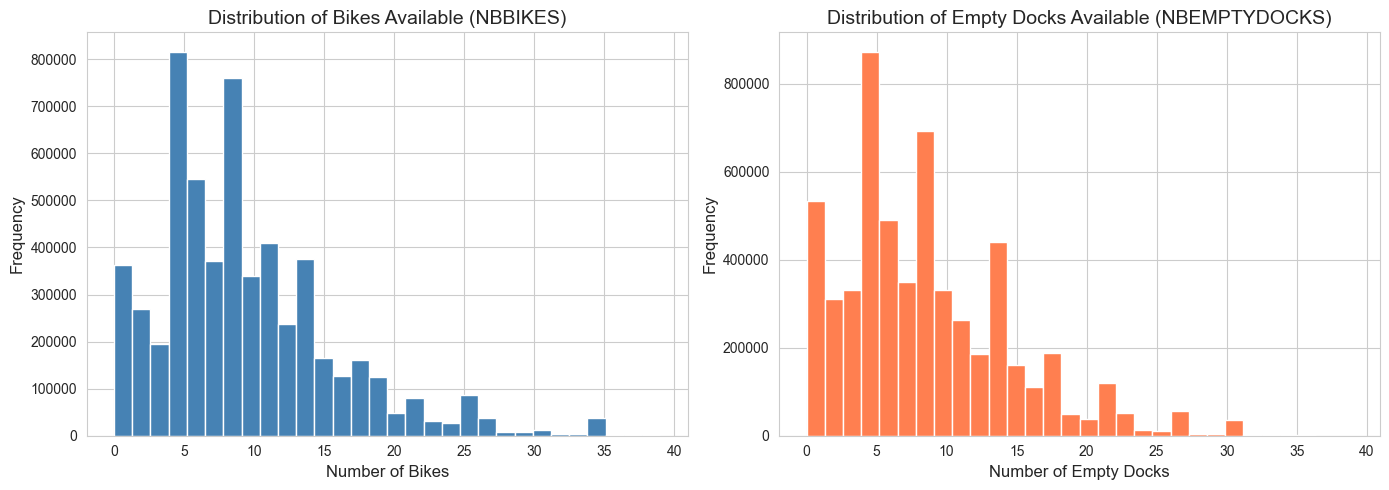

Plot saved.


In [32]:
# Distribution of NBBIKES and NBEMPTYDOCKS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['NBBIKES'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Bikes Available (NBBIKES)')
axes[0].set_xlabel('Number of Bikes')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['NBEMPTYDOCKS'].dropna(), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Empty Docks Available (NBEMPTYDOCKS)')
axes[1].set_xlabel('Number of Empty Docks')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()
print('Plot saved.')

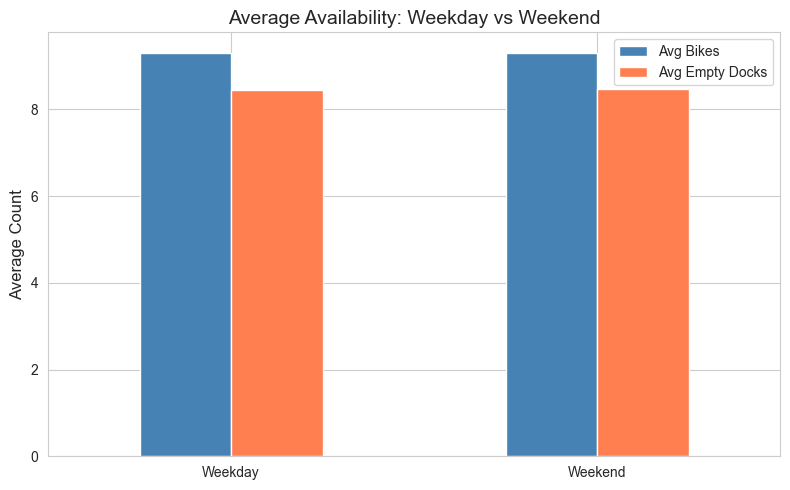

Plot saved.


In [34]:
# Weekday vs Weekend comparison
weekend_comp = df.groupby('is_weekend')[['NBBIKES', 'NBEMPTYDOCKS']].mean().round(2)
weekend_comp.index = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(8, 5))
weekend_comp.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
ax.set_title('Average Availability: Weekday vs Weekend')
ax.set_xlabel('')
ax.set_ylabel('Average Count')
ax.set_xticklabels(['Weekday', 'Weekend'], rotation=0)
ax.legend(['Avg Bikes', 'Avg Empty Docks'])
plt.tight_layout()
plt.savefig('weekday_vs_weekend.png', dpi=150)
plt.show()
print('Plot saved.')

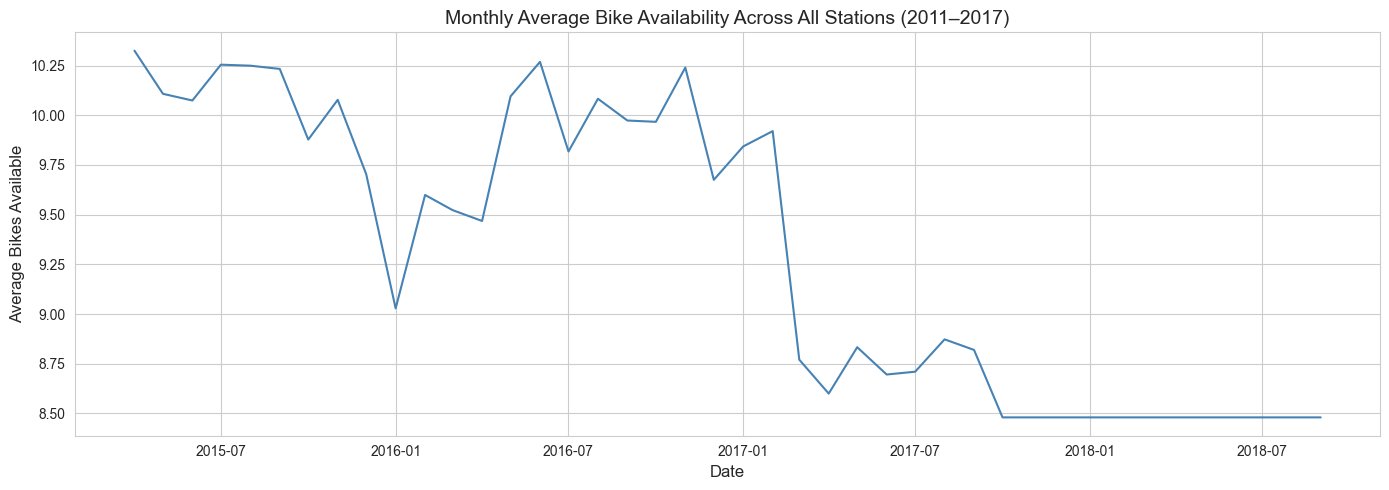

Plot saved.


In [36]:
# Monthly trend across years
monthly = df.groupby(['year', 'month'])['NBBIKES'].mean().reset_index()
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['date'], monthly['NBBIKES'], color='steelblue', linewidth=1.5)
ax.set_title('Monthly Average Bike Availability Across All Stations (2011–2017)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Bikes Available')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()
print('Plot saved.')

## 9. Summary of Findings

From the exploratory analysis completed so far:

- The dataset contains station-level readings recorded at regular intervals across multiple years
- Missing values are present in some columns (REMOVALDATE, INSTALLDATE) which are not critical for the core analysis
- The `RUNDATE` column has been successfully parsed into datetime format and time-based features have been extracted
- Station pressure analysis reveals which stations most frequently experience near-empty or near-full conditions
- Hourly and daily patterns show clear peak and off-peak periods across the network
- Lag and rolling features have been engineered to support future modelling for bike and dock availability prediction

**Next steps:**
- Build baseline forecasting models for NBBIKES and NBEMPTYDOCKS
- Evaluate models using MAE and RMSE across different time horizons (+1h, +3h, +6h)
- Explore graph-based approaches to capture spatial relationships between stations